In [6]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### K-Nearest Neighbors (KNN)

The **k-nearest neighbor (KNN)** classifier is a fundamental machine learning algorithm that is categorized as a **lazy learner**. Unlike parametric models that learn a discriminative function from training data, KNN belongs to a subcategory of non-parametric models known as **instance-based learning**, meaning it effectively "memorizes" the training dataset to make predictions.

---

### Parametric vs. Non-Parametric Models

* **Parametric Models:** (e.g., Logistic Regression, Linear SVM) These models estimate a fixed set of parameters from the training data to learn a function. Once the parameters are learned, the original training data is no longer needed for classification.
* **Non-Parametric Models:** (e.g., KNN, Decision Trees, Random Forests) These models cannot be characterized by a fixed set of parameters. The complexity and "parameters" of the model grow with the amount of training data.

---

### The KNN Algorithm Steps

The execution of the KNN algorithm is straightforward and follows these three steps:

1.  **Choose the value of $k$** (the number of neighbors) and a **distance metric**.
2.  **Find the $k$-nearest neighbors** of the data record you want to classify.
3.  **Assign the class label** based on a majority vote among those neighbors.

---

### Advantages and Disadvantages

**Advantages**

- **Instant Adaptation:** The classifier adapts immediately as new training data is collected.

- **No Training Cost:** Since it is a "lazy" learner, there is zero cost during the learning phase.

- **Predictive Performance:** Can provide high accuracy on small to medium-sized datasets.

**Disadvantages**

- **Computational Complexity:** The cost of classifying new examples grows linearly with the number of samples in the dataset.

- **Storage Requirements:** Large datasets can be problematic due to limited storage capacities, as the entire dataset must be retained.

- **The Curse of Dimensionality:** Highly susceptible to overfitting in high-dimensional spaces where data becomes sparse.


---

### Mathematical Foundation: Distance Metrics

The choice of distance metric is crucial. A common generalization is the **Minkowski distance**, which can be written as:

$$d(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = \sqrt[p]{\sum_{k} |x_k^{(i)} - x_k^{(j)}|^p}$$

* When **$p=2$**, this is the **Euclidean distance**.
* When **$p=1$**, this is the **Manhattan distance**.

**Note:** It is essential to **standardize** the data before using KNN so that all features contribute equally to the distance calculation.

---

### Key Considerations for Implementation

* **Hyperparameter Tuning:** The choice of $k$ is vital for balancing overfitting and underfitting.
* **Tie-Breaking:** In scikit-learn, ties are resolved by preferring the closer neighbor or the label that appears first in the training set.
* **Dimensionality:** To avoid the "curse of dimensionality," use feature selection or dimensionality reduction techniques (like PCA) rather than regularization, which is not applicable to KNN.

In [7]:
X_combined_std, y_combined, X_train_std, X_test_std, y_train, y_test = data_reader()

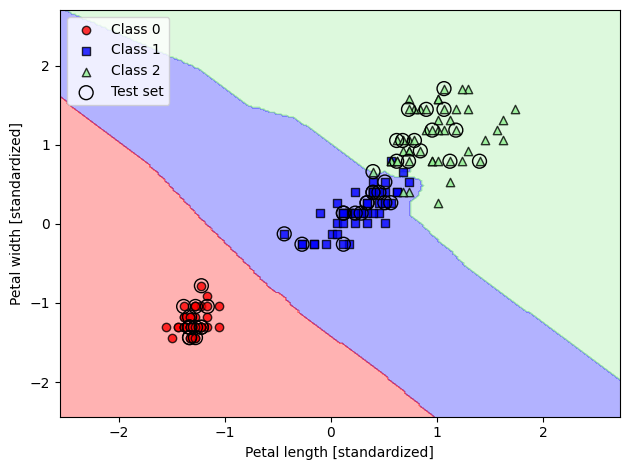

In [8]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, p=2,
                            metric='minkowski')
knn.fit(X_train_std, y_train)
plot_decision_regions(X_combined_std, y_combined,
                       classifier=knn, test_idx=range(105,150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()